# NB01 — CSV Extraction and Database Population
**TCC Weathering ML — Schema v2.2**

Extracts **all** data from the ECCC ESTS CSV (494 rows × 356 columns) into SQLite:

| Section | CSV Rows | Target Table | Records (est.) |
|---|---|---|---|
| Oil metadata | 0-7 | `oils` | ~120 |
| Density (3 temps) | 9-20 | `sample_properties` | ~1,000 |
| API Gravity | 21 | `sample_properties` | ~350 |
| Dynamic Viscosity (3T × 6 shear) | 23-95 | `sample_properties` | ~6,000 |
| Surface/Interfacial Tension | 96-132 | `sample_properties` | ~3,000 |
| Flash Point, Vapor Pressure, Pour Point | 133-146 | `sample_properties` | ~1,000 |
| Boiling Point Distribution (SIMDIS) | 148-191 | `sample_properties` | ~15,000 |
| Adhesion | 192-196 | `sample_properties` | ~350 |
| Evaporation Equations | 197-204 | `evaporation_equations` | ~300 |
| Pan Evaporation (29 timepoints) | 206-235 | `pan_evaporation` | ~3,500 |
| Emulsion (rheology, 2 timepoints) | 237-288 | `sample_properties` | ~4,000 |
| Dispersibility, Sulfur, Water | 289-303 | `sample_properties` | ~1,000 |
| BTEX + Alkylbenzenes | 304-323 | `sample_properties` | ~2,500 |
| PHC Fractions + SARA + Wax | 324-381 | `sample_properties` | ~10,000 |
| n-Alkanes + Isoprenoids | 382-420 | `measurements` + `compounds` | ~14,000 |
| Alkylated PAHs | 423-454 | `measurements` + `compounds` | ~11,000 |
| Other Priority PAHs | 455-469 | `measurements` + `compounds` | ~5,000 |
| Biomarkers | 472-492 | `measurements` + `compounds` | ~7,000 |

**Estimated total:** ~85,000 records across 5 tables.

---


## 1. Setup

Import shared infrastructure from `utils.py` (paths, connection, seed).
All NB01-specific paths (CSV, figure directory) are defined here.
The CSV is the ECCC ESTS database (2021-01-22 English version).


In [1]:
import sys
import sqlite3
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import json
from pathlib import Path
from collections import defaultdict, Counter
from itertools import groupby
from IPython.display import Image, display
try:
    from scipy import stats as sp_stats
except ImportError:
    sp_stats = None
    print('⚠️  scipy not available — consistency checks will be skipped')

from utils import get_conn, PROJECT_ROOT, DB_PATH, SEED
CSV_PATH     = PROJECT_ROOT / "data" / "raw" / "ECCC_Petroleum_Products_Database-2021-01-22.EN.csv"
FIG_DIR      = PROJECT_ROOT / "figures" / "nb01"  # NB-specific subfolder
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

assert DB_PATH.exists(), f"Database not found: {DB_PATH}. Run NB00 first."
assert CSV_PATH.exists(), f"CSV not found: {CSV_PATH}"
print(f"Database: {DB_PATH} ({DB_PATH.stat().st_size:,} bytes)")
print(f"CSV: {CSV_PATH}")


Database: C:\Users\leogr\Documents\Data Science\TCC\data\processed\weathering.db (6,053,888 bytes)
CSV: C:\Users\leogr\Documents\Data Science\TCC\data\raw\ECCC_Petroleum_Products_Database-2021-01-22.EN.csv


## 2. Load CSV and parse structure

The ECCC CSV has a transposed layout: 494 rows × 356 columns.
Rows 0-7 are metadata (oil name, source, ESTS code, weathering state, mass loss).
Rows 8+ are data (properties, compounds). Each column from index 5 onward is
one sample (oil × weathering state). We parse the metadata rows into `sample_meta`
and compute a SHA-256 hash for reproducibility tracking.


In [2]:
# Load entire CSV — no header, latin-1 encoding
raw = pd.read_csv(CSV_PATH, encoding='latin-1', header=None, low_memory=False)
print(f"CSV shape: {raw.shape}")

# Sample columns start at index 5
SAMPLE_COLS = list(range(5, raw.shape[1]))
N_SAMPLES = len(SAMPLE_COLS)
print(f"Sample columns: {N_SAMPLES}")

# ── Extract sample metadata (rows 0-7) ──
sample_meta = pd.DataFrame({
    'col_idx':    SAMPLE_COLS,
    'oil_name':   [str(raw.iloc[0, j]).strip() for j in SAMPLE_COLS],
    'source':     [str(raw.iloc[1, j]).strip() for j in SAMPLE_COLS],
    'date_received': [str(raw.iloc[2, j]).strip() for j in SAMPLE_COLS],
    'comments':   [str(raw.iloc[3, j]).strip() for j in SAMPLE_COLS],
    'ests_code':  [str(raw.iloc[4, j]).strip() for j in SAMPLE_COLS],
    'stage_code': [str(raw.iloc[5, j]).strip() for j in SAMPLE_COLS],
    'mass_loss':  [str(raw.iloc[6, j]).strip() for j in SAMPLE_COLS],
    'weathering_method': [str(raw.iloc[7, j]).strip() for j in SAMPLE_COLS],
})
# Clean 'nan' strings
for col in sample_meta.columns:
    sample_meta[col] = sample_meta[col].replace('nan', None)

# Normalize stage codes
stage_map = {
    'Before water content correction': 'BWC',
    'After drying (water content correction )': 'AWC',
}
sample_meta['stage_code'] = sample_meta['stage_code'].map(
    lambda x: stage_map.get(x, x) if x else x
)

print(f"\nUnique oils: {sample_meta['oil_name'].nunique()}")
print(f"Stage distribution:\n{sample_meta['stage_code'].value_counts().to_string()}")

# ── CSV reproducibility hash ──
import hashlib
csv_hash = hashlib.sha256(CSV_PATH.read_bytes()).hexdigest()
print(f'CSV SHA-256: {csv_hash[:16]}...')
with get_conn() as conn:
    conn.execute(
        "INSERT OR REPLACE INTO db_metadata VALUES ('csv_sha256', ?, datetime('now'))",
        (csv_hash,)
    )
    conn.execute(
        "INSERT OR REPLACE INTO db_metadata VALUES ('csv_filename', ?, datetime('now'))",
        (CSV_PATH.name,)
    )
print('✓ CSV hash persisted in db_metadata')


CSV shape: (494, 356)
Sample columns: 351

Unique oils: 120
Stage distribution:
stage_code
W0      106
W3       88
W2       64
W1       63
W4        9
B5        7
B100      6
B20       6
BWC       1
AWC       1
CSV SHA-256: 71e8fc355fae1430...
✓ CSV hash persisted in db_metadata


## 3. Helper functions

Four functions handle the repetitive structure of the CSV:
- `parse_numeric`: converts CSV cells to float, handling ND/NM/nan/% gracefully.
- `parse_temperature`: extracts °C from strings like '15°C', 'Room Temperature'.
- `extract_block`: generic extractor for the 4-row pattern (value, SD, replicates,
  method) that repeats ~30 times across the CSV. Called 12 times in this notebook.
- `insert_sample_properties`: batch inserts records into the EAV table, resolving
  oil names to database IDs.


In [3]:
def parse_numeric(val):
    """Parse a CSV cell to float. Returns None for ND, NM, nan, empty, %."""
    if val is None:
        return None
    s = str(val).strip()
    if s in ('', 'nan', 'ND', 'NM', 'NM ', 'ND '):
        return None
    s = s.rstrip('%').strip()
    try:
        return float(s)
    except ValueError:
        return None


def parse_temperature(val):
    """Parse temperature string like '15°C', '5°C', 'Room Temperature'."""
    if val is None:
        return None
    s = str(val).strip()
    if s in ('nan', ''):
        return None
    if 'Room' in s:
        return 22.0  # conventional room temperature
    m = re.search(r'(-?\d+\.?\d*)\s*°?\s*C', s)
    if m:
        return float(m.group(1))
    return None


def extract_block(raw, row_val, row_sd, row_rep, row_method,
                  property_name, sample_meta, temperature_c=None,
                  condition=None, unit=None):
    """
    Extract a 4-row property block (value, SD, replicates, method)
    for all samples. Returns list of dicts ready for DB insert.
    
    Parameters
    ----------
    raw : DataFrame — the full CSV
    row_val, row_sd, row_rep, row_method : int — row indices
    property_name : str — e.g. 'density', 'viscosity'
    sample_meta : DataFrame — with col_idx, oil_name, stage_code
    temperature_c : float or None — override; if None, parsed from col 3
    condition : str or None — override; if None, parsed from col 4
    unit : str or None — override; if None, parsed from col 2
    """
    records = []
    if temperature_c is None:
        temperature_c = parse_temperature(raw.iloc[row_val, 3])
    if unit is None:
        u = str(raw.iloc[row_val, 2]).strip()
        unit = u if u != 'nan' else None
    if condition is None:
        c = str(raw.iloc[row_val, 4]).strip()
        condition = c if c != 'nan' else None
    
    method_val = str(raw.iloc[row_method, 5]).strip() if row_method else None
    if method_val == 'nan':
        method_val = None
    
    for _, sm in sample_meta.iterrows():
        j = sm['col_idx']
        v = parse_numeric(raw.iloc[row_val, j])
        if v is None:
            continue  # skip missing
        sd = parse_numeric(raw.iloc[row_sd, j]) if row_sd else None
        reps = parse_numeric(raw.iloc[row_rep, j]) if row_rep else None
        # Per-sample method (some vary)
        m = str(raw.iloc[row_method, j]).strip() if row_method else method_val
        if m == 'nan':
            m = method_val
        records.append({
            'oil_name':      sm['oil_name'],
            'stage_code':    sm['stage_code'],
            'property_name': property_name,
            'temperature_c': temperature_c,
            'condition':     condition,
            'value':         v,
            'unit':          unit,
            'std_dev':       sd,
            'replicates':    int(reps) if reps is not None else None,
            'method':        m,
        })
    return records


def insert_sample_properties(conn, records, oil_id_map):
    """Insert records into sample_properties, resolving oil_name → oil_id."""
    inserted = 0
    for r in records:
        oid = oil_id_map.get(r['oil_name'])
        if oid is None:
            continue
        try:
            conn.execute(
                """INSERT OR IGNORE INTO sample_properties
                   (oil_id, stage_code, property_name, temperature_c,
                    condition, value, unit, std_dev, replicates, method)
                   VALUES (?,?,?,?,?,?,?,?,?,?)""",
                (oid, r['stage_code'], r['property_name'], r['temperature_c'],
                 r['condition'], r['value'], r['unit'], r['std_dev'],
                 r['replicates'], r['method'])
            )
            inserted += 1
        except sqlite3.IntegrityError:
            pass  # UNIQUE constraint — skip duplicates
    return inserted

print("✓ Helper functions defined")


✓ Helper functions defined


## 4. Oil registry

Classify all 120+ unique oil names into `oil_type`, detect multi-vintage groups,
and set `include_in_analysis` (1 = has W0+W1+W2+W3 and is petroleum, not biodiesel).


In [4]:
def classify_oil(name):
    """Classify oil by name into oil_type."""
    low = name.lower()
    if 'biodiesel' in low:
        return 'biodiesel'
    if 'orimulsion' in low:
        return 'orimulsion'
    if 'bunker' in low or 'fuel oil' in low or 'ifo' in low:
        return 'fuel_oil'
    if low.startswith('cold lake bitumen') or low == 'rail bitumen':
        return 'bitumen'
    if 'synthetic' in low and 'blend' not in low:
        return 'synthetic'
    if any(k in low for k in ['blend', 'dilbit']):
        return 'bitumen_blend'
    if any(k in low for k in ['diesel', 'marine diesel', 'marine safe lube']):
        return 'refined'
    # Albian Heavy Synthetic — no 'blend', has 'synthetic'
    if 'albian' in low:
        return 'synthetic'
    return 'crude'


def parse_vintage(name):
    """Extract [YYYY] vintage year and base name."""
    m = re.search(r'\[(\d{4}[a-z]?)\]', name)
    if m:
        year = m.group(1)
        base = name[:m.start()].strip()
        return base, year
    return name, None


# ── Build oil registry ──
unique_oils = sample_meta['oil_name'].dropna().unique()
oil_stages = defaultdict(set)
for _, row in sample_meta.iterrows():
    if row['oil_name']:
        oil_stages[row['oil_name']].add(row['stage_code'])

oil_records = []
base_counts = defaultdict(list)
for name in sorted(unique_oils):
    base, vintage = parse_vintage(name)
    otype = classify_oil(name)
    stages = oil_stages[name]
    has_full = {'W0', 'W1', 'W2', 'W3'}.issubset(stages)
    include = 1 if (has_full and otype not in ('biodiesel', 'orimulsion')) else 0
    exclude_reason = None
    if not include:
        reasons = []
        if not has_full:
            reasons.append(f'Missing stages (has {sorted(stages)})')
        if otype in ('biodiesel', 'orimulsion'):
            reasons.append(f'Product type: {otype}')
        exclude_reason = '; '.join(reasons)
    base_counts[base].append(name)
    # Get first sample's metadata
    first = sample_meta[sample_meta['oil_name'] == name].iloc[0]
    oil_records.append({
        'oil_name': name, 'base_name': base, 'vintage_year': vintage,
        'oil_type': otype, 'include_in_analysis': include,
        'exclude_reason': exclude_reason,
        'source': first['source'], 'date_received': first['date_received'],
        'ests_code': first['ests_code'], 'comments': first['comments'],
    })

# Detect multi-vintage groups
multi_vintage_groups = {base: names for base, names in base_counts.items() if len(names) > 1}
for rec in oil_records:
    if rec['base_name'] in multi_vintage_groups:
        rec['is_multi_vintage'] = 1
        rec['vintage_group'] = rec['base_name']
    else:
        rec['is_multi_vintage'] = 0
        rec['vintage_group'] = None

df_oils = pd.DataFrame(oil_records)
print(f"Total unique oils: {len(df_oils)}")
print(f"\noil_type distribution:")
print(df_oils.groupby('oil_type')['include_in_analysis'].agg(['count', 'sum']).rename(
    columns={'count': 'total', 'sum': 'included'}))
print(f"\nMulti-vintage groups: {len(multi_vintage_groups)}")
for base, names in sorted(multi_vintage_groups.items()):
    print(f"  {base}: {names}")


Total unique oils: 120

oil_type distribution:
               total  included
oil_type                      
biodiesel         16         0
bitumen            2         0
bitumen_blend     10         9
crude             67        44
fuel_oil          11         0
orimulsion         1         0
refined           10         7
synthetic          3         2

Multi-vintage groups: 7
  Alaska North Slope: ['Alaska North Slope [2002]', 'Alaska North Slope [2010]', 'Alaska North Slope [2011]', 'Alaska North Slope [2012]', 'Alaska North Slope [2015]']
  Cold Lake Blend Winter: ['Cold Lake Blend Winter [2013]', 'Cold Lake Blend Winter [2015]', 'Cold Lake Blend Winter [2018]', 'Cold Lake Blend Winter [2019]']
  Hibernia: ['Hibernia [1999]', 'Hibernia [2018]']
  IFO 180: ['IFO 180', 'IFO 180 [2004]']
  Sweet Synthetic Crude Oil: ['Sweet Synthetic Crude Oil [2015a]', 'Sweet Synthetic Crude Oil [2015b]']
  Terra Nova: ['Terra Nova [2011]', 'Terra Nova [2018]']
  White Rose: ['White Rose [2000]', 'W

## 5. Insert oils into database

Inserts all ~120 oils with a master DELETE that respects foreign key order
(children before parents). This makes the notebook fully idempotent —
re-running clears everything and rebuilds from scratch.[
        # NB01 only deletes tables IT populates.
        # ON DELETE CASCADE in the schema handles downstream FK dependencies.
        # Each downstream NB (NB02, NB03, NB04...) cleans its own tables.
        'measurements',           # → compounds, oils
        'sample_properties',      # → oils
        'pan_evaporation',        # → oils
        'evaporation_equations',  # → oils
        'oil_weathering_kinetics',# → oils
        'compounds',              # → (parent)
        'oils',                   # → (root parent — CASCADE deletes all children)
    ]## 5. Insert oils into database

Inserts all ~120 oils with a master DELETE that respects foreign key order
(children before parents). This makes the notebook fully idempotent —
re-running clears everything and rebuilds from scratch.


In [5]:
with get_conn() as conn:
    # Clear existing data (idempotent re-run)
    # NB01 only deletes tables IT populates.
    # ON DELETE CASCADE in the schema handles downstream FK dependencies.
    # Each downstream NB (NB02, NB03, NB04...) cleans its own tables.
    for child_table in [
        'measurements',           # → compounds, oils
        'sample_properties',      # → oils
        'pan_evaporation',        # → oils
        'evaporation_equations',  # → oils
        'oil_weathering_kinetics',# → oils
        'compounds',              # → (parent)
        'oils',                   # → (root parent — CASCADE deletes all children)
    ]:
        try:
            conn.execute(f"DELETE FROM {child_table}")
        except Exception:
            pass  # table may not exist yet or be empty
    
    for _, rec in df_oils.iterrows():
        conn.execute(
            """INSERT INTO oils
               (oil_name, base_name, vintage_year, region, oil_type,
                is_multi_vintage, vintage_group,
                include_in_analysis, exclude_reason, notes,
                source, date_received, ests_code, comments)
               VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?)""",
            (rec['oil_name'], rec['base_name'], rec['vintage_year'],
             None,  # region — to be filled manually if needed
             rec['oil_type'], rec['is_multi_vintage'], rec['vintage_group'],
             rec['include_in_analysis'], rec['exclude_reason'], None,
             rec['source'], rec['date_received'], rec['ests_code'], rec['comments'])
        )
    
    # Build oil_id lookup
    oil_id_map = dict(conn.execute(
        "SELECT oil_name, oil_id FROM oils"
    ).fetchall())

n_included = sum(1 for r in oil_records if r['include_in_analysis'])
print(f"\u2713 {len(oil_id_map)} oils inserted ({n_included} included in analysis)")


✓ 120 oils inserted (62 included in analysis)


## 6. Oil type classification audit

Review all oil classifications for correctness.
Manual verification required — pattern matching is not infallible.


In [6]:
# Display full classification for human review
with get_conn() as conn:
    df_audit = pd.read_sql("""
        SELECT oil_name, oil_type, include_in_analysis, exclude_reason,
               is_multi_vintage, vintage_group
        FROM oils ORDER BY oil_type, oil_name
    """, conn)

print(f'Oil type classification ({len(df_audit)} oils):')
print(f'  Included: {df_audit["include_in_analysis"].sum()}')
print(f'  Excluded: {(~df_audit["include_in_analysis"].astype(bool)).sum()}')
print()
for otype in df_audit['oil_type'].unique():
    subset = df_audit[df_audit['oil_type'] == otype]
    incl = subset['include_in_analysis'].sum()
    print(f'  {otype} ({len(subset)} total, {incl} included):')
    for _, row in subset.iterrows():
        flag = '✓' if row['include_in_analysis'] else '✗'
        print(f'    {flag} {row["oil_name"]}')
    print()

print('⚠️  Review above classifications. If any oil_type is wrong,')
print('   correct classify_oil() and re-run NB01.')


Oil type classification (120 oils):
  Included: 62
  Excluded: 58

  biodiesel (16 total, 0 included):
    ✗ Biodiesel Canola B100
    ✗ Biodiesel Canola B20
    ✗ Biodiesel Canola B5
    ✗ Biodiesel Canola-B100
    ✗ Biodiesel Canola-B20
    ✗ Biodiesel Canola-B5
    ✗ Biodiesel Soy B100
    ✗ Biodiesel Soy B20
    ✗ Biodiesel Soy B5
    ✗ Biodiesel Soy-1002-B100
    ✗ Biodiesel Soy-1002-B20
    ✗ Biodiesel Soy-1002-B5
    ✗ Biodiesel Tallow B100
    ✗ Biodiesel Tallow B20
    ✗ Biodiesel Tallow B5
    ✗ Diesel Echo Bay (B5 Biodiesel)

  bitumen (2 total, 0 included):
    ✗ Cold Lake Bitumen [1988]
    ✗ Rail Bitumen

  bitumen_blend (10 total, 9 included):
    ✓ Access West Blend Winter
    ✓ Alberta Sweet Mixed Blend #4
    ✓ Alberta Sweet Mixed Blend #5
    ✗ Alberta Sweet Mixed Blend #6
    ✓ Cold Lake Blend Summer [2014]
    ✓ Cold Lake Blend Winter [2013]
    ✓ Cold Lake Blend Winter [2015]
    ✓ Cold Lake Blend Winter [2018]
    ✓ Cold Lake Blend Winter [2019]
    ✓ Synthetic B

## 7. Physical properties

Extract density (3T), API gravity, dynamic viscosity (3T × 6 shear rates),
surface/interfacial tension (3T × 3 types), flash point, vapor pressure, pour point.


In [7]:
all_props = []  # accumulate all records, insert in batch
# Performance note: O(n_samples × n_properties) iteration via iterrows().
# For ~85k records this takes 1-3 min. Vectorization with pandas operations
# would give 5-10× speedup but adds complexity. Acceptable for single execution.

# ── Mass loss per sample (row 6) — CRITICAL for weathering_stages stats ──
# Methodological note: mass loss is computed as (mi-mf)/(mi-me) × 100%
# where mi=initial mass, mf=final mass, me=empty flask (ECCC method 12.01).
# W1/W2/W3 fractions are ~1/3, 2/3, and full 48h of rotary evaporation at 80°C.
for _, sm in sample_meta.iterrows():
    if sm['oil_name'] is None or sm['stage_code'] is None:
        continue
    ml_str = str(sm.get('mass_loss', '')).strip()
    if ml_str and ml_str != 'None':
        v = parse_numeric(ml_str)
        if v is not None:
            all_props.append({
                'oil_name': sm['oil_name'], 'stage_code': sm['stage_code'],
                'property_name': 'evaporative_mass_loss', 'temperature_c': None,
                'condition': None, 'value': v, 'unit': '% w/w',
                'std_dev': None, 'replicates': None, 'method': None,
            })
print(f"Mass loss: {len(all_props)} records")

# ── Weathering method per sample (row 7) — persist as property ──
n_wm = 0
for _, sm in sample_meta.iterrows():
    if sm['oil_name'] is None or sm['stage_code'] is None:
        continue
    wm = sm.get('weathering_method')
    if wm and wm != 'None':
        # Store method name as ordinal: pan_evaporation=1, rotary_evaporation=2, other=0
        wm_lower = str(wm).lower().strip()
        if 'pan' in wm_lower:
            wm_val = 1
        elif 'rotar' in wm_lower:
            wm_val = 2
        else:
            wm_val = 0
        all_props.append({
            'oil_name': sm['oil_name'], 'stage_code': sm['stage_code'],
            'property_name': 'weathering_method', 'temperature_c': None,
            'condition': wm, 'value': wm_val, 'unit': 'ordinal',
            'std_dev': None, 'replicates': None, 'method': None,
        })
        n_wm += 1
print(f"Weathering method: {n_wm} records")


# ── Density (rows 9-20): 3 temperatures, each with 4-row block ──
density_blocks = [
    (9, 10, 11, 12),    # 15°C
    (13, 14, 15, 16),   # 5°C
    (17, 18, 19, 20),   # 0°C
]
for rv, rs, rr, rm in density_blocks:
    all_props.extend(extract_block(raw, rv, rs, rr, rm, 'density', sample_meta))
print(f"Density: {len(all_props)} records")

# ── API Gravity (row 21) — no SD/replicates ──
n0 = len(all_props)
for _, sm in sample_meta.iterrows():
    v = parse_numeric(raw.iloc[21, sm['col_idx']])
    if v is not None:
        all_props.append({
            'oil_name': sm['oil_name'], 'stage_code': sm['stage_code'],
            'property_name': 'api_gravity', 'temperature_c': None,
            'condition': None, 'value': v, 'unit': None,
            'std_dev': None, 'replicates': None, 'method': None,
        })
print(f"API Gravity: {len(all_props) - n0} records")

# ── Dynamic Viscosity (rows 23-95): 3T × 6 shear conditions ──
n0 = len(all_props)
visc_conditions = [
    ('newtonian', 0), ('shear_100', 4), ('shear_10', 8),
    ('shear_1', 12), ('shear_0.1', 16), ('unknown', 20),
]
visc_temps = [(23, '15'), (47, '5'), (71, '0')]  # base row for each temp
for base_row, temp_label in visc_temps:
    for cond_name, offset in visc_conditions:
        rv = base_row + offset
        rs = rv + 1
        rr = rv + 2
        rm = rv + 3
        all_props.extend(extract_block(
            raw, rv, rs, rr, rm, 'dynamic_viscosity', sample_meta,
            condition=cond_name
        ))
print(f"Viscosity: {len(all_props) - n0} records")

# ── Surface / Interfacial Tension (rows 96-132): 3T × 3 types ──
n0 = len(all_props)
tension_blocks = [
    # (row_val, row_sd, row_rep, row_method, property, temp)
    (96, 97, 98, 99, 'surface_tension', None),
    (100, 101, 102, 103, 'interfacial_tension_oil_freshwater', None),  # Oil/water
    (104, 105, 106, 107, 'interfacial_tension_oil_seawater', None),    # Oil/3.3% NaCl
    (108, 109, 110, 111, 'surface_tension', None),
    (112, 113, 114, 115, 'interfacial_tension_oil_freshwater', None),  # Oil/water
    (116, 117, 118, 119, 'interfacial_tension_oil_seawater', None),    # Oil/3.3% NaCl
    (120, 121, 122, 123, 'surface_tension', None),
    (124, 125, 126, 127, 'interfacial_tension_oil_freshwater', None),  # Oil/water
    (128, 129, 130, 131, 'interfacial_tension_oil_seawater', None),    # Oil/3.3% NaCl
]
for rv, rs, rr, rm, pname, _ in tension_blocks:
    all_props.extend(extract_block(raw, rv, rs, rr, rm, pname, sample_meta))
print(f"Tension: {len(all_props) - n0} records")

# ── Flash Point (rows 133-137) ──
n0 = len(all_props)
all_props.extend(extract_block(raw, 133, 134, 135, 136, 'flash_point', sample_meta))
print(f"Flash Point: {len(all_props) - n0} records")

# ── Vapor Pressure (rows 138-142) ──
n0 = len(all_props)
all_props.extend(extract_block(raw, 138, 139, 140, 141, 'vapor_pressure', sample_meta))
print(f"Vapor Pressure: {len(all_props) - n0} records")

# ── Pour Point (rows 143-146) ──
n0 = len(all_props)
all_props.extend(extract_block(raw, 143, 144, 145, 146, 'pour_point', sample_meta))
print(f"Pour Point: {len(all_props) - n0} records")

print(f"\nTotal physical properties: {len(all_props)} records")


Mass loss: 329 records
Weathering method: 224 records
Density: 1269 records
API Gravity: 324 records
Viscosity: 710 records
Tension: 1033 records
Flash Point: 252 records
Vapor Pressure: 11 records
Pour Point: 251 records

Total physical properties: 3850 records


## 8. Boiling Point Distribution (SIMDIS)

Simulated distillation: 22 temperature percentiles (IBP, 5%-95%, FBP) and
19 cumulative weight fractions at temperature thresholds (40°C-700°C).
The cumulative rows all share the same col 1 label — the discriminator is
the temperature in col 3, which we use as the property name suffix.


In [8]:
# ── Boiling Point: Temperature Distribution (rows 148-169) ──
# Row 148: IBP, rows 149-167: 5%-95%, row 168: FBP, row 169: 100%
n0 = len(all_props)
bp_labels = ['IBP'] + [f'{p}%' for p in range(5, 100, 5)] + ['FBP', '100%']
bp_rows = list(range(148, 170))
for row_idx, label in zip(bp_rows, bp_labels):
    for _, sm in sample_meta.iterrows():
        v = parse_numeric(raw.iloc[row_idx, sm['col_idx']])
        if v is not None:
            all_props.append({
                'oil_name': sm['oil_name'], 'stage_code': sm['stage_code'],
                'property_name': f'bp_temperature_{label}',
                'temperature_c': None, 'condition': 'SIMDIS',
                'value': v, 'unit': '°C',
                'std_dev': None, 'replicates': None, 'method': None,
            })

# ── Boiling Point: Cumulative Weight Fraction (rows 171-189) ──
# All rows have same col 1 label; the TEMPERATURE THRESHOLD is in col 3
bp_cum_rows = list(range(171, 190))
for row_idx in bp_cum_rows:
    temp_threshold = parse_numeric(raw.iloc[row_idx, 3])  # 40, 60, ..., 700
    if temp_threshold is None:
        continue
    pname = f'bp_cumulative_{int(temp_threshold)}C'
    for _, sm in sample_meta.iterrows():
        v = parse_numeric(raw.iloc[row_idx, sm['col_idx']])
        if v is not None:
            all_props.append({
                'oil_name': sm['oil_name'], 'stage_code': sm['stage_code'],
                'property_name': pname,
                'temperature_c': temp_threshold, 'condition': 'SIMDIS_cumulative',
                'value': v, 'unit': '% w/w',
                'std_dev': None, 'replicates': None, 'method': None,
            })

print(f"Boiling Point: {len(all_props) - n0} records")


Boiling Point: 3448 records


## 9. Adhesion

Oil adhesion (g/m²) measured at room temperature (~22°C).
Mass of oil remaining on a standard stainless steel surface after 30 min drainage.


In [9]:
n0 = len(all_props)
all_props.extend(extract_block(raw, 192, 193, 194, 195, 'adhesion', sample_meta))
print(f"Adhesion: {len(all_props) - n0} records")


Adhesion: 118 records


## 10. Evaporation equations (Fingas models)

Three empirical models fit to pan evaporation data:
- `ln`: %Ev = (A + B(T-15)) × ln(t) — logarithmic model
- `sqrt`: %Ev = (A + B(T-15)) × √t — square root model
- `ln_C`: %Ev = A + B × ln(t+C) — shifted logarithmic

Coefficients A, B, (C) per oil. Only ~30 oils have fitted equations
(vs ~62 with raw pan evaporation data).


In [10]:
evap_eq_records = []

eq_types = [
    ('ln',    197, 198, None),  # A, B for %Ev = (A+B) ln(t)
    ('sqrt',  199, 200, None),  # A, B for %Ev = (A+B) sqrt(t)
    ('ln_C',  201, 202, 203),   # A, B, C for %Ev = A + B ln(t+C)
]

for eq_type, row_a, row_b, row_c in eq_types:
    for _, sm in sample_meta.iterrows():
        if sm['stage_code'] != 'W0':
            continue  # equations are per oil, not per stage
        a = parse_numeric(raw.iloc[row_a, sm['col_idx']])
        b = parse_numeric(raw.iloc[row_b, sm['col_idx']])
        c = parse_numeric(raw.iloc[row_c, sm['col_idx']]) if row_c else None
        if a is not None or b is not None:
            evap_eq_records.append({
                'oil_name': sm['oil_name'],
                'equation_type': eq_type,
                'coeff_a': a, 'coeff_b': b, 'coeff_c': c,
            })

print(f"Evaporation equations: {len(evap_eq_records)} records")
# Distribution by type
type_counts = Counter(r['equation_type'] for r in evap_eq_records)
for t, n in sorted(type_counts.items()):
    print(f"  {t}: {n} oils")


Evaporation equations: 39 records
  ln: 19 oils
  ln_C: 9 oils
  sqrt: 11 oils


## 11. Pan evaporation (29 timepoints, 15°C)

Raw evaporative mass loss measured in a petri dish at 15°C under controlled
airflow (ECCC method 12.16/2.0/M and 12.16/3.0/M). 29 timepoints from 0h
to 672h (4 weeks). Data is already smoothed by 3-hour moving average
before reporting.

This is a SEPARATE measurement from the rotary evaporation (80°C) that
produces the W0-W3 samples. Pan evaporation reflects ambient-like conditions.


In [11]:
pan_evap_records = []

# Time labels in CSV (rows 206-234)
pan_times_h = [
    0, 0.05, 0.1, 0.25, 0.5, 1, 2, 4, 8, 12, 18, 24,
    36, 48, 72, 96, 120, 144, 168, 192, 216, 240, 264,
    288, 312, 336, 448, 560, 672
]
pan_rows = list(range(206, 235))  # 29 rows

for row_idx, time_h in zip(pan_rows, pan_times_h):
    for _, sm in sample_meta.iterrows():
        if sm['stage_code'] != 'W0':
            continue  # pan evaporation is per oil (measured once at W0)
        v = parse_numeric(raw.iloc[row_idx, sm['col_idx']])
        if v is not None:
            pan_evap_records.append({
                'oil_name': sm['oil_name'],
                'time_hours': time_h,
                'mass_loss_pct': v,
            })

n_oils_pan = len(set(r['oil_name'] for r in pan_evap_records))
print(f"Pan evaporation: {len(pan_evap_records)} records from {n_oils_pan} oils")


Pan evaporation: 1479 records from 62 oils


## 12. Emulsion properties

Two timepoints: day-of-formation (rows 237-261) and one-week-after (rows 263-287).
Each has: visual stability, complex modulus, storage modulus, loss modulus,
tan delta, complex viscosity, water content.


In [12]:
n0 = len(all_props)

# Emulsion property blocks: (value_row, sd_row, rep_row, name, timepoint)
emulsion_blocks = [
    # Day of formation
    (237, None, None, 'emulsion_visual_stability_day0', 'day_of_formation'),
    (239, 240, 241, 'emulsion_complex_modulus_day0', 'day_of_formation'),
    (242, 243, 244, 'emulsion_storage_modulus_day0', 'day_of_formation'),
    (245, 246, 247, 'emulsion_loss_modulus_day0', 'day_of_formation'),
    (249, 250, 251, 'emulsion_tan_delta_day0', 'day_of_formation'),
    (253, 254, 255, 'emulsion_complex_viscosity_day0', 'day_of_formation'),
    (257, 258, 259, 'emulsion_water_content_day0', 'day_of_formation'),
    # One week after
    (263, None, None, 'emulsion_visual_stability_1wk', 'one_week'),
    (265, 266, 267, 'emulsion_complex_modulus_1wk', 'one_week'),
    (268, 269, 270, 'emulsion_storage_modulus_1wk', 'one_week'),
    (271, 272, 273, 'emulsion_loss_modulus_1wk', 'one_week'),
    (275, 276, 277, 'emulsion_tan_delta_1wk', 'one_week'),
    (279, 280, 281, 'emulsion_complex_viscosity_1wk', 'one_week'),
    (283, 284, 285, 'emulsion_water_content_1wk', 'one_week'),
]

for rv, rs, rr, pname, tp in emulsion_blocks:
    if rs is not None:
        all_props.extend(extract_block(raw, rv, rs, rr, None, pname, sample_meta,
                                        condition=tp))
    else:
        # Visual stability — categorical, store as value
        for _, sm in sample_meta.iterrows():
            v_str = str(raw.iloc[rv, sm['col_idx']]).strip()
            if v_str not in ('nan', '', 'ND', 'NM'):
                # Decision D-EMULSION: ordinal encoding of visual stability.
                # Unstable(0) < Entrained(1) < Meso-stable(2) < Stable(3).
                # This is an analytical choice — alternative: keep as categorical.
                stab_map = {'Unstable': 0, 'Entrained': 1, 'Meso-stable': 2, 'Stable': 3}
                v = stab_map.get(v_str)
                if v is None:
                    v = parse_numeric(v_str)
                if v is None and v_str not in ('nan', '', 'ND', 'NM'):
                    print(f'  ⚠️  Unmapped emulsion value: "{v_str}" '
                          f'(oil={sm["oil_name"]}, stage={sm["stage_code"]})')
                if v is not None:
                    all_props.append({
                        'oil_name': sm['oil_name'], 'stage_code': sm['stage_code'],
                        'property_name': pname, 'temperature_c': 15.0,
                        'condition': tp, 'value': v, 'unit': 'ordinal',
                        'std_dev': None, 'replicates': None, 'method': None,
                    })

print(f"Emulsion: {len(all_props) - n0} records")


  ⚠️  Unmapped emulsion value: "Did not form" (oil=Access West Blend Winter, stage=W4)
  ⚠️  Unmapped emulsion value: "Mesostable" (oil=Alaska North Slope [2002], stage=W3)
  ⚠️  Unmapped emulsion value: "Did not form" (oil=Alaska North Slope [2011], stage=W0)
  ⚠️  Unmapped emulsion value: "Mesostable" (oil=Alaska North Slope [2011], stage=W2)
  ⚠️  Unmapped emulsion value: "Mesostable" (oil=Alaska North Slope [2011], stage=W3)
  ⚠️  Unmapped emulsion value: "Did not form" (oil=Alaska North Slope [2012], stage=W0)
  ⚠️  Unmapped emulsion value: "Did not form" (oil=Alaska North Slope [2012], stage=W1)
  ⚠️  Unmapped emulsion value: "Mesostable" (oil=Alaska North Slope [2012], stage=W3)
  ⚠️  Unmapped emulsion value: "Mesostable" (oil=Alaska North Slope [2015], stage=W3)
  ⚠️  Unmapped emulsion value: "Mesostable" (oil=Alberta Sweet Mixed Blend #5, stage=W0)
  ⚠️  Unmapped emulsion value: "Mesostable" (oil=Alberta Sweet Mixed Blend #5, stage=W1)
  ⚠️  Unmapped emulsion value: "Mesostabl

## 13. Dispersibility, Sulfur, Water content

- **Dispersibility**: effectiveness of Corexit 9500 dispersant at 15°C (ASTM F2059).
- **Sulfur**: total sulfur by energy-dispersive XRF (ASTM D4294).
- **Water content**: Karl Fischer titration (ASTM E203).


In [13]:
n0 = len(all_props)
all_props.extend(extract_block(raw, 289, 290, 291, 292, 'dispersant_effectiveness', sample_meta))
all_props.extend(extract_block(raw, 294, 295, 296, 297, 'sulfur_content', sample_meta))
all_props.extend(extract_block(raw, 299, 300, 301, 302, 'water_content', sample_meta))
print(f"Dispersibility + Sulfur + Water: {len(all_props) - n0} records")


Dispersibility + Sulfur + Water: 524 records


## 14. Bulk chemistry: BTEX, Alkylbenzenes, PHC fractions, SARA, Wax

These are bulk/aggregate chemical properties, not individual compounds.
They go into `sample_properties`, not `measurements`.


In [14]:
n0 = len(all_props)

# ── BTEX (rows 304-309): individual BTEX compounds as properties ──
btex_map = {
    304: 'btex_benzene', 305: 'btex_toluene', 306: 'btex_ethylbenzene',
    307: 'btex_mp_xylene', 308: 'btex_o_xylene',
}
for row_idx, pname in btex_map.items():
    for _, sm in sample_meta.iterrows():
        v = parse_numeric(raw.iloc[row_idx, sm['col_idx']])
        if v is not None:
            all_props.append({
                'oil_name': sm['oil_name'], 'stage_code': sm['stage_code'],
                'property_name': pname, 'temperature_c': None,
                'condition': None, 'value': v, 'unit': 'ug/g',
                'std_dev': None, 'replicates': None, 'method': None,
            })
print(f"BTEX: {len(all_props) - n0} records")
# ── L4: Compute BTEX total (sum of 5 components) ──
n_btex_total = 0
btex_components = ['btex_benzene', 'btex_toluene', 'btex_ethylbenzene',
                   'btex_mp_xylene', 'btex_o_xylene']
# Group by oil×stage, sum
btex_records = [r for r in all_props if r['property_name'] in btex_components]
btex_records.sort(key=lambda r: (r['oil_name'] or '', r['stage_code'] or ''))
for key, grp in groupby(btex_records, key=lambda r: (r['oil_name'], r['stage_code'])):
    vals = [r['value'] for r in grp if r['value'] is not None]
    if vals:
        all_props.append({
            'oil_name': key[0], 'stage_code': key[1],
            'property_name': 'btex_total', 'temperature_c': None,
            'condition': None, 'value': sum(vals), 'unit': 'ug/g',
            'std_dev': None, 'replicates': None, 'method': 'computed_sum',
        })
        n_btex_total += 1
print(f"BTEX total (computed): {n_btex_total} records")


# ── C3-C6 Alkyl Benzenes (rows 310-323) ──
n1 = len(all_props)
for row_idx in range(310, 324):
    label = str(raw.iloc[row_idx, 1]).strip()
    if label in ('nan', 'Standard deviation', 'Replicates', 'Method'):
        continue
    pname = f'alkylbenzene_{label.replace(" ", "_").replace(",", "")}'
    for _, sm in sample_meta.iterrows():
        v = parse_numeric(raw.iloc[row_idx, sm['col_idx']])
        if v is not None:
            all_props.append({
                'oil_name': sm['oil_name'], 'stage_code': sm['stage_code'],
                'property_name': pname, 'temperature_c': None,
                'condition': None, 'value': v, 'unit': 'ug/g',
                'std_dev': None, 'replicates': None, 'method': None,
            })
print(f"Alkylbenzenes: {len(all_props) - n1} records")

# ── PHC fractions (rows 324-366) ──
n1 = len(all_props)
phc_sections = {
    'GC-Detected': range(324, 331),
    'CCME': range(332, 337),
    'Saturates_fraction': range(338, 346),
    'Aromatics_fraction': range(347, 355),
    'TPH_total': range(356, 366),
}
for section, row_range in phc_sections.items():
    for row_idx in row_range:
        label = str(raw.iloc[row_idx, 1]).strip()
        if label in ('nan', 'Standard deviation', 'Replicates', 'Method'):
            continue
        pname = f'phc_{section}_{label.replace(" ", "_").replace("/", "_")}'
        unit = str(raw.iloc[row_idx, 2]).strip()
        unit = unit if unit != 'nan' else None
        for _, sm in sample_meta.iterrows():
            v = parse_numeric(raw.iloc[row_idx, sm['col_idx']])
            if v is not None:
                all_props.append({
                    'oil_name': sm['oil_name'], 'stage_code': sm['stage_code'],
                    'property_name': pname, 'temperature_c': None,
                    'condition': None, 'value': v, 'unit': unit,
                    'std_dev': None, 'replicates': None, 'method': None,
                })
# Normalize key TPH name for downstream queries
for rec in all_props:
    pn = rec['property_name']
    if 'Gas Chromatography-Total petroleum hydrocarbon' in pn:
        rec['property_name'] = 'phc_gc_tph'
    elif 'Gas Chromatography-Total saturate' in pn:
        rec['property_name'] = 'phc_gc_tsh'
    elif 'Gas Chromatography-Total aromatic' in pn:
        rec['property_name'] = 'phc_gc_tah'

print(f"PHC fractions: {len(all_props) - n1} records")

# ── SARA (rows 367-376) ──
n1 = len(all_props)
# SARA: Sat(367), Aro(368) have no individual SD.
# Resin(369) has SD(370)/Rep(371). Asphaltene(372) has SD(373)/Rep(374).
sara_blocks = [
    (367, None, None, 'sara_saturates'),
    (368, None, None, 'sara_aromatics'),
    (369, 370, 371, 'sara_resins'),
    (372, 373, 374, 'sara_asphaltenes'),
]
for rv, rs, rr, pname in sara_blocks:
    for _, sm in sample_meta.iterrows():
        v = parse_numeric(raw.iloc[rv, sm['col_idx']])
        if v is None:
            continue
        sd = parse_numeric(raw.iloc[rs, sm['col_idx']]) if rs else None
        reps = parse_numeric(raw.iloc[rr, sm['col_idx']]) if rr else None
        all_props.append({
            'oil_name': sm['oil_name'], 'stage_code': sm['stage_code'],
            'property_name': pname, 'temperature_c': None,
            'condition': None, 'value': v, 'unit': '% w/w',
            'std_dev': sd,
            'replicates': int(reps) if reps is not None else None,
            'method': None,
        })
print(f"SARA: {len(all_props) - n1} records")

# ── Wax (row 377) ──
n1 = len(all_props)
for _, sm in sample_meta.iterrows():
    v = parse_numeric(raw.iloc[377, sm['col_idx']])
    if v is not None:
        all_props.append({
            'oil_name': sm['oil_name'], 'stage_code': sm['stage_code'],
            'property_name': 'wax_content', 'temperature_c': None,
            'condition': None, 'value': v, 'unit': '% w/w',
            'std_dev': None, 'replicates': None, 'method': None,
        })
print(f"Wax: {len(all_props) - n1} records")

print(f"\n{'='*50}")
print(f"TOTAL sample_properties records: {len(all_props)}")


BTEX: 405 records
BTEX total (computed): 93 records
Alkylbenzenes: 748 records
PHC fractions: 4221 records
SARA: 944 records
Wax: 178 records

TOTAL sample_properties records: 15908


## 15. Insert sample_properties into database

Batch insert of all accumulated records (~50k+) into the EAV table.
Uses INSERT OR IGNORE for idempotency — duplicate (oil, stage, property,
temperature, condition) tuples are silently skipped.


In [15]:
with get_conn() as conn:
    inserted = insert_sample_properties(conn, all_props, oil_id_map)

print(f"✓ {inserted} records inserted into sample_properties")
print(f"  (skipped {len(all_props) - inserted} — missing oil_id or duplicates)")


✓ 15908 records inserted into sample_properties
  (skipped 0 — missing oil_id or duplicates)


## 16. Physical bounds validation

Verify extracted values fall within physically plausible ranges.
Catches parsing errors that statistical outlier detection would miss.


In [16]:
PHYSICAL_BOUNDS = {
    'density':          (0.60, 1.20, 'g/mL'),     # lightest condensate to heavy bitumen
    'api_gravity':      (-5, 80, '°API'),          # heavy bitumen to condensate
    'pour_point':       (-70, 80, '°C'),           # Arctic crude to waxy crude
    'flash_point':      (-50, 400, '°C'),          # gasoline to heavy residual
    'vapor_pressure':   (0, 200, 'kPa'),           # non-volatile to light condensate
    'sulfur_content':   (0, 10, '% w/w'),          # sweet to very sour
    'wax_content':      (0, 50, '% w/w'),          # wax-free to waxy crude
    'sara_saturates':   (0, 100, '% w/w'),
    'sara_aromatics':   (0, 100, '% w/w'),
    'sara_resins':      (0, 100, '% w/w'),
    'sara_asphaltenes': (0, 50, '% w/w'),          # rarely > 30%
}

with get_conn() as conn:
    n_violations = 0
    for prop, (lo, hi, unit) in PHYSICAL_BOUNDS.items():
        violations = conn.execute("""
            SELECT o.oil_name, sp.stage_code, sp.value
            FROM sample_properties sp
            JOIN oils o ON sp.oil_id = o.oil_id
            WHERE sp.property_name = ?
              AND (sp.value < ? OR sp.value > ?)
        """, (prop, lo, hi)).fetchall()
        if violations:
            for name, stage, val in violations:
                print(f'  ⚠️  {prop}: {name} ({stage}) = {val} {unit} '
                      f'[expected {lo}–{hi}]')
                n_violations += 1

if n_violations == 0:
    print('✓ All values within physical bounds')
else:
    print(f'\n⚠️  {n_violations} values outside physical bounds — review above')


  ⚠️  pour_point: Alaminos Canyon Block 25 (W0) = -72.0 °C [expected -70–80]
  ⚠️  pour_point: Amauligak (W0) = -78.0 °C [expected -70–80]
  ⚠️  pour_point: Marine Safe Lube (W0) = -81.0 °C [expected -70–80]

⚠️  3 values outside physical bounds — review above


## 17. Insert evaporation equations

Persist Fingas model coefficients. ~30 oils have fitted equations.


In [17]:
with get_conn() as conn:
    inserted = 0
    for r in evap_eq_records:
        oid = oil_id_map.get(r['oil_name'])
        if oid is None:
            continue
        conn.execute(
            """INSERT OR IGNORE INTO evaporation_equations
               (oil_id, equation_type, coeff_a, coeff_b, coeff_c)
               VALUES (?,?,?,?,?)""",
            (oid, r['equation_type'], r['coeff_a'], r['coeff_b'], r['coeff_c'])
        )
        inserted += 1

print(f"✓ {inserted} records inserted into evaporation_equations")


✓ 39 records inserted into evaporation_equations


## 18. Insert pan evaporation

Persist raw pan evaporation time series. ~62 oils × 29 timepoints.


In [18]:
with get_conn() as conn:
    inserted = 0
    for r in pan_evap_records:
        oid = oil_id_map.get(r['oil_name'])
        if oid is None:
            continue
        conn.execute(
            """INSERT OR IGNORE INTO pan_evaporation
               (oil_id, time_hours, mass_loss_pct, temperature_c)
               VALUES (?,?,?,15.0)""",
            (oid, r['time_hours'], r['mass_loss_pct'])
        )
        inserted += 1

n_oils_inserted = len(set(r['oil_name'] for r in pan_evap_records if r['oil_name'] in oil_id_map))
print(f"✓ {inserted} records inserted into pan_evaporation ({n_oils_inserted} oils)")


✓ 1479 records inserted into pan_evaporation (62 oils)


## Compounds and Measurements

Extract individual chemical compounds (n-alkanes, isoprenoids, PAHs, biomarkers)
into `compounds` and `measurements` tables. These feed the ML pipeline.

**Analytical context (ECCC method 5.03/x.x/M):** Values are **semi-quantitative**
(GC-MS peak areas relative to internal standards: 5-α-androstane for alkanes,
C30-ββ-hopane for biomarkers, d₁₄-terphenyl for PAHs). Not absolute concentrations.
Diagnostic ratios (NB02) cancel the response factor, making them robust to
inter-sample calibration differences. All measurements are means of triplicates.


In [19]:
# ── Define compound groups ──
compound_defs = []

# n-Alkanes (rows 382-420, excluding Pristane/Phytane)
alkane_rows = list(range(382, 421))
isoprenoid_rows = [392, 394]  # Pristane (392), Phytane (394)
for row_idx in alkane_rows:
    name = str(raw.iloc[row_idx, 1]).strip()
    if name in ('nan', 'Standard deviation', 'Replicates', 'Method'):
        continue
    if row_idx in isoprenoid_rows:
        group = 'isoprenoid'
    else:
        group = 'n_alkane'
    # Extract carbon number
    cn_match = re.search(r'C(\d+)', name)
    cn = int(cn_match.group(1)) if cn_match else None
    compound_defs.append({'name': name, 'group': group, 'carbon_number': cn,
                          'row': row_idx})

# Alkylated PAHs (rows 423-454)
for row_idx in range(423, 455):
    name = str(raw.iloc[row_idx, 1]).strip()
    if name in ('nan', 'Standard deviation', 'Replicates', 'Method'):
        continue
    compound_defs.append({'name': name, 'group': 'pah_alkylated',
                          'carbon_number': None, 'row': row_idx})

# Other Priority PAHs (rows 455-469)
for row_idx in range(455, 470):
    name = str(raw.iloc[row_idx, 1]).strip()
    if name in ('nan', 'Standard deviation', 'Replicates', 'Method'):
        continue
    compound_defs.append({'name': name, 'group': 'pah_priority',
                          'carbon_number': None, 'row': row_idx})

# Biomarkers (rows 472-492)
for row_idx in range(472, 493):
    name = str(raw.iloc[row_idx, 1]).strip()
    if name in ('nan', 'Standard deviation', 'Replicates', 'Method'):
        continue
    # Classify biomarker subtype
    low = name.lower()
    if 'tricyclic' in low:
        group = 'biomarker_terpane'
    elif 'hopane' in low or 'norhopane' in low:
        group = 'biomarker_hopane'
    elif 'cholestane' in low:
        group = 'biomarker_sterane'
    else:
        group = 'biomarker_hopane'  # default
    compound_defs.append({'name': name, 'group': group,
                          'carbon_number': None, 'row': row_idx})

print(f"Compound definitions: {len(compound_defs)}")
grp_counts = Counter(c['group'] for c in compound_defs)
for g, n in sorted(grp_counts.items()):
    print(f"  {g}: {n}")

# ── Normalize special characters in compound names (I4) ──
# CSV has: ß (eszett), Méthyl (accented e), Éthyl (accented E)
# Standardize to ASCII-compatible names matching compound_name_mapping
char_fixes = {
    # CHG-0004 (23/apr/2026): 'ß' preserved — compound_name_mapping.md uses ß
    # as canonical (14ß(H),17ß(H)-Cholestane C27aßß etc.). Removal of the
    # old entry "'ß': 'ss'" (F-NB01-m3). Only the French accents are ASCII-fied.
    'Méthyl': 'Methyl',
    'Éthyl': 'Ethyl',
}
for cdef in compound_defs:
    for old_char, new_char in char_fixes.items():
        cdef['name'] = cdef['name'].replace(old_char, new_char)

# Verify no remaining non-ASCII in compound names (excluding ß which is intentional)
import unicodedata
for cdef in compound_defs:
    for ch in cdef['name']:
        if ord(ch) > 127 and ch != 'ß':
            print(f"  ⚠️ Non-ASCII in '{cdef['name']}': U+{ord(ch):04X} '{ch}'")

print(f"\n✓ Compound names normalized ({len(compound_defs)} compounds)")
# Show sterane names
for cdef in compound_defs:
    if 'Cholestane' in cdef['name']:
        print(f"  {cdef['name']}")


Compound definitions: 107
  biomarker_hopane: 14
  biomarker_sterane: 3
  biomarker_terpane: 4
  isoprenoid: 2
  n_alkane: 37
  pah_alkylated: 32
  pah_priority: 15

✓ Compound names normalized (107 compounds)
  14ß(H),17ß(H)-20-Cholestane (C27aßß)
  20-Methyl-14ß(H),17ß(H)-Cholestane (C28aßß)
  20-Ethyl-14ß(H),17ß(H)-Cholestane (C29aßß)


## 20. Insert compounds and measurements

Insert ~107 compounds into `compounds` table, then ~35k measurement records
into `measurements`. Each measurement preserves both `value_raw` (original CSV
value, NULL for ND/NM) and `value_imputed` (ND→0 per decision D15).
The `is_nd` and `is_imputed` flags maintain full provenance.


In [20]:
with get_conn() as conn:
    # Clear existing (idempotent)
    
    # Insert compounds
    compound_id_map = {}
    for cdef in compound_defs:
        conn.execute(
            """INSERT INTO compounds
               (compound_name, compound_group, carbon_number,
                is_normalizator, eccc_row_index)
               VALUES (?,?,?,?,?)""",
            (cdef['name'], cdef['group'], cdef['carbon_number'],
             1 if cdef['name'] == 'Hopane (H30)' else 0,
             cdef['row'])
        )
        compound_id_map[cdef['name']] = conn.execute(
            "SELECT last_insert_rowid()").fetchone()[0]
    
    print(f"✓ {len(compound_id_map)} compounds inserted")
    
    # Insert measurements
    n_meas = 0
    n_nd = 0
    batch = []
    
    for cdef in compound_defs:
        cid = compound_id_map[cdef['name']]
        row_idx = cdef['row']
        
        for _, sm in sample_meta.iterrows():
            if sm['oil_name'] is None:
                continue
            oid = oil_id_map.get(sm['oil_name'])
            if oid is None:
                continue
            
            raw_str = str(raw.iloc[row_idx, sm['col_idx']]).strip()
            is_nd = 1 if raw_str in ('ND', 'NM', 'ND ', 'NM ') else 0
            v = parse_numeric(raw.iloc[row_idx, sm['col_idx']])
            
            # Imputation: ND → 0 (decision D15)
            v_imputed = 0.0 if (is_nd and v is None) else v
            is_imputed = 1 if (is_nd and v is None) else 0
            
            if is_nd:
                n_nd += 1
            
            batch.append(
                (oid, sm['stage_code'], cid, v, v_imputed, is_nd, is_imputed)
            )
            n_meas += 1
    
    conn.executemany(
        """INSERT OR IGNORE INTO measurements
           (oil_id, stage_code, compound_id, value_raw, value_imputed,
            is_nd, is_imputed)
           VALUES (?,?,?,?,?,?,?)""",
        batch
    )

print(f"✓ {n_meas} measurements inserted ({n_nd} ND values imputed to 0)")


✓ 107 compounds inserted
✓ 37557 measurements inserted (234 ND values imputed to 0)


## 20a. Reconciliation guard — canonical compound names (CHG-0006)


In [21]:
# ── Reconciliation guard (FIX-NB01-1, CHG-0006, 24/abr/2026) ──
# Regression guard for F-NB01-C1 (ß→ss transliteration). Verifies that all
# compound names referenced by NB02 CANONICAL_RATIOS + DOUGLAS_RATIOS +
# TERNARY_RATIOS + sterane_cols are present in compounds.compound_name with
# correct encoding. Fails HERE (producer) instead of silently propagating to
# NB02 (consumer) where a miss becomes "skipped ratio" in cell 14.
#
# NOTE: this list is a hardcoded subset synchronized manually with NB02
# CANONICAL_RATIOS. compound_name_mapping.md is the authoritative source.
# If NB02 adds new canonical ratios, extend this list.

CANONICAL_COMPOUND_NAMES = {
    # Alkylated naphthalenes (full series)
    'C0-Naphthalene', 'C1-Naphthalene', 'C2-Naphthalene',
    'C3-Naphthalene', 'C4-Naphthalene',
    # Alkylated phenanthrenes, DBTs, fluorenes (endpoints used in canonical ratios)
    'C0-Phenanthrene', 'C4-Phenanthrene',
    'C0-Dibenzothiophene', 'C3-Dibenzothiophene',
    'C0-Fluorene', 'C3-Fluorene',
    # Biomarkers (hopanes & terpanes)
    'Hopane (H30)', '30-Norhopane (H29)',
    '30-Homohopane-22S (H31S)', '30-Homohopane-22R (H31R)',
    '30,31-Bishomohopane-22S (H32S)', '30,31-Bishomohopane-22R (H32R)',
    '18a,22,29,30-trisnorneohopane (C27Ts)',
    '17a(H)-22,29,30-Trisnorhopane (C27Tm)',
    'C23 tricyclic terpane (C23T)', 'C24 tricyclic terpane (C24T)',
    # Steranes — ß preservation is the F-NB01-C1 regression target
    '14ß(H),17ß(H)-20-Cholestane (C27aßß)',
    '20-Methyl-14ß(H),17ß(H)-Cholestane (C28aßß)',
    '20-Ethyl-14ß(H),17ß(H)-Cholestane (C29aßß)',
    # n-alkanes referenced in canonical ratios
    'n-C10', 'n-C12', 'n-C17', 'n-C18', 'n-C20', 'n-C24',
    # Isoprenoids
    'Pristane', 'Phytane',
}

with get_conn() as conn:
    present = {row[0] for row in conn.execute(
        "SELECT compound_name FROM compounds"
    ).fetchall()}

missing = CANONICAL_COMPOUND_NAMES - present
if missing:
    msg = (
        f"F-NB01-C1 regression: {len(missing)} canonical compound name(s) "
        f"not found in compounds table:\n"
    )
    for m in sorted(missing):
        msg += f"  - {m!r}\n"
    msg += (
        "\nCheck cell 38 char_fixes dict, CSV parsing, or compound_defs "
        "construction. compound_name_mapping.md is the authoritative reference."
    )
    raise AssertionError(msg)

print(f"✓ All {len(CANONICAL_COMPOUND_NAMES)} canonical compound names present "
      f"(F-NB01-C1 guard passed)")


✓ All 32 canonical compound names present (F-NB01-C1 guard passed)


## 20b. Compute `missing_pct` and `excluded` for compounds

For the 45 included oils (W0-W3), compute the percentage of NULL/ND values
per compound. Compounds with ≥50% missing are marked `excluded=1`.


In [22]:
with get_conn() as conn:
    # Count missing per compound across included oils × 4 stages
    results = conn.execute("""
        SELECT c.compound_id, c.compound_name,
               COUNT(*) as n_total,
               SUM(CASE WHEN m.value_raw IS NULL THEN 1 ELSE 0 END) as n_missing
        FROM compounds c
        JOIN measurements m ON c.compound_id = m.compound_id
        JOIN oils o ON m.oil_id = o.oil_id
        WHERE o.include_in_analysis = 1
          AND m.stage_code IN ('W0', 'W1', 'W2', 'W3')
        GROUP BY c.compound_id
    """).fetchall()
    
    n_excluded = 0
    for cid, cname, n_total, n_missing in results:
        pct = (n_missing / n_total * 100) if n_total > 0 else 100.0
        excluded = 1 if pct >= 50.0 else 0
        reason = f'{pct:.1f}% missing (>= 50% threshold)' if excluded else None
        conn.execute(
            """UPDATE compounds
               SET missing_pct = ?, excluded = ?, exclude_reason = ?
               WHERE compound_id = ?""",
            (round(pct, 2), excluded, reason, cid)
        )
        if excluded:
            n_excluded += 1
    
    n_active = len(results) - n_excluded

print(f"✓ missing_pct computed for {len(results)} compounds")
print(f"  Active: {n_active}, Excluded (>=50% missing): {n_excluded}")
print(f"  Expected: ~92 active, ~15 excluded")
if n_active not in range(85, 100):
    print(f"  ⚠️  UNEXPECTED: {n_active} active compounds — verify!")


✓ missing_pct computed for 107 compounds
  Active: 92, Excluded (>=50% missing): 15
  Expected: ~92 active, ~15 excluded


## 21. Update `oils` table with W0 scalar properties

Copy key W0 properties (API gravity, pour point, density, flash point,
sulfur, wax) from `sample_properties` into `oils` for quick access.
These are used by NB05 (correlations with MAE) and NB08 (clustering).
Vapor pressure is handled separately (has temperature_c = 37.8, not NULL).


In [23]:
with get_conn() as conn:
    # Map property_name → oils column
    # Properties where temperature_c IS NULL at W0
    prop_to_col_null_temp = {
        'api_gravity':    'api_gravity',
        'pour_point':     'pour_point_c',
        'flash_point':    'flash_point_c',
        'sulfur_content': 'sulfur_pct',
        'wax_content':    'wax_pct',
    }
    # Properties with specific temperature (vapor_pressure at 37.8°C)
    prop_to_col_any_temp = {
        'vapor_pressure': 'vapor_pressure_kpa',
    }
    
    updated = {}
    for prop_name, col_name in prop_to_col_null_temp.items():
        rows = conn.execute(
            """SELECT oil_id, value FROM sample_properties
               WHERE property_name = ? AND stage_code = 'W0'
               AND temperature_c IS NULL AND condition IS NULL""",
            (prop_name,)
        ).fetchall()
        for oid, val in rows:
            conn.execute(f"UPDATE oils SET {col_name} = ? WHERE oil_id = ?",
                         (val, oid))
        updated[col_name] = len(rows)
    
    for prop_name, col_name in prop_to_col_any_temp.items():
        rows = conn.execute(
            """SELECT oil_id, value FROM sample_properties
               WHERE property_name = ? AND stage_code = 'W0'
               ORDER BY oil_id""",
            (prop_name,)
        ).fetchall()
        for oid, val in rows:
            conn.execute(f"UPDATE oils SET {col_name} = ? WHERE oil_id = ?",
                         (val, oid))
        updated[col_name] = len(rows)
    
    # Density at 15°C — needs temperature filter
    rows = conn.execute(
        """SELECT oil_id, value FROM sample_properties
           WHERE property_name = 'density' AND stage_code = 'W0'
           AND temperature_c = 15.0"""
    ).fetchall()
    for oid, val in rows:
        conn.execute("UPDATE oils SET density_15c = ? WHERE oil_id = ?", (val, oid))
    updated['density_15c'] = len(rows)

for col, n in updated.items():
    print(f"  {col}: {n} oils updated")


  api_gravity: 96 oils updated
  pour_point_c: 75 oils updated
  flash_point_c: 52 oils updated
  sulfur_pct: 71 oils updated
  wax_pct: 67 oils updated
  vapor_pressure_kpa: 7 oils updated
  density_15c: 103 oils updated


## 22. Missingness heatmap

Visual overview of data completeness: oils (rows) × property sections (columns).
Green = data present, red = missing. Identifies oils with incomplete profiles
and property sections with systematic gaps. Saved as PNG for the dissertation.


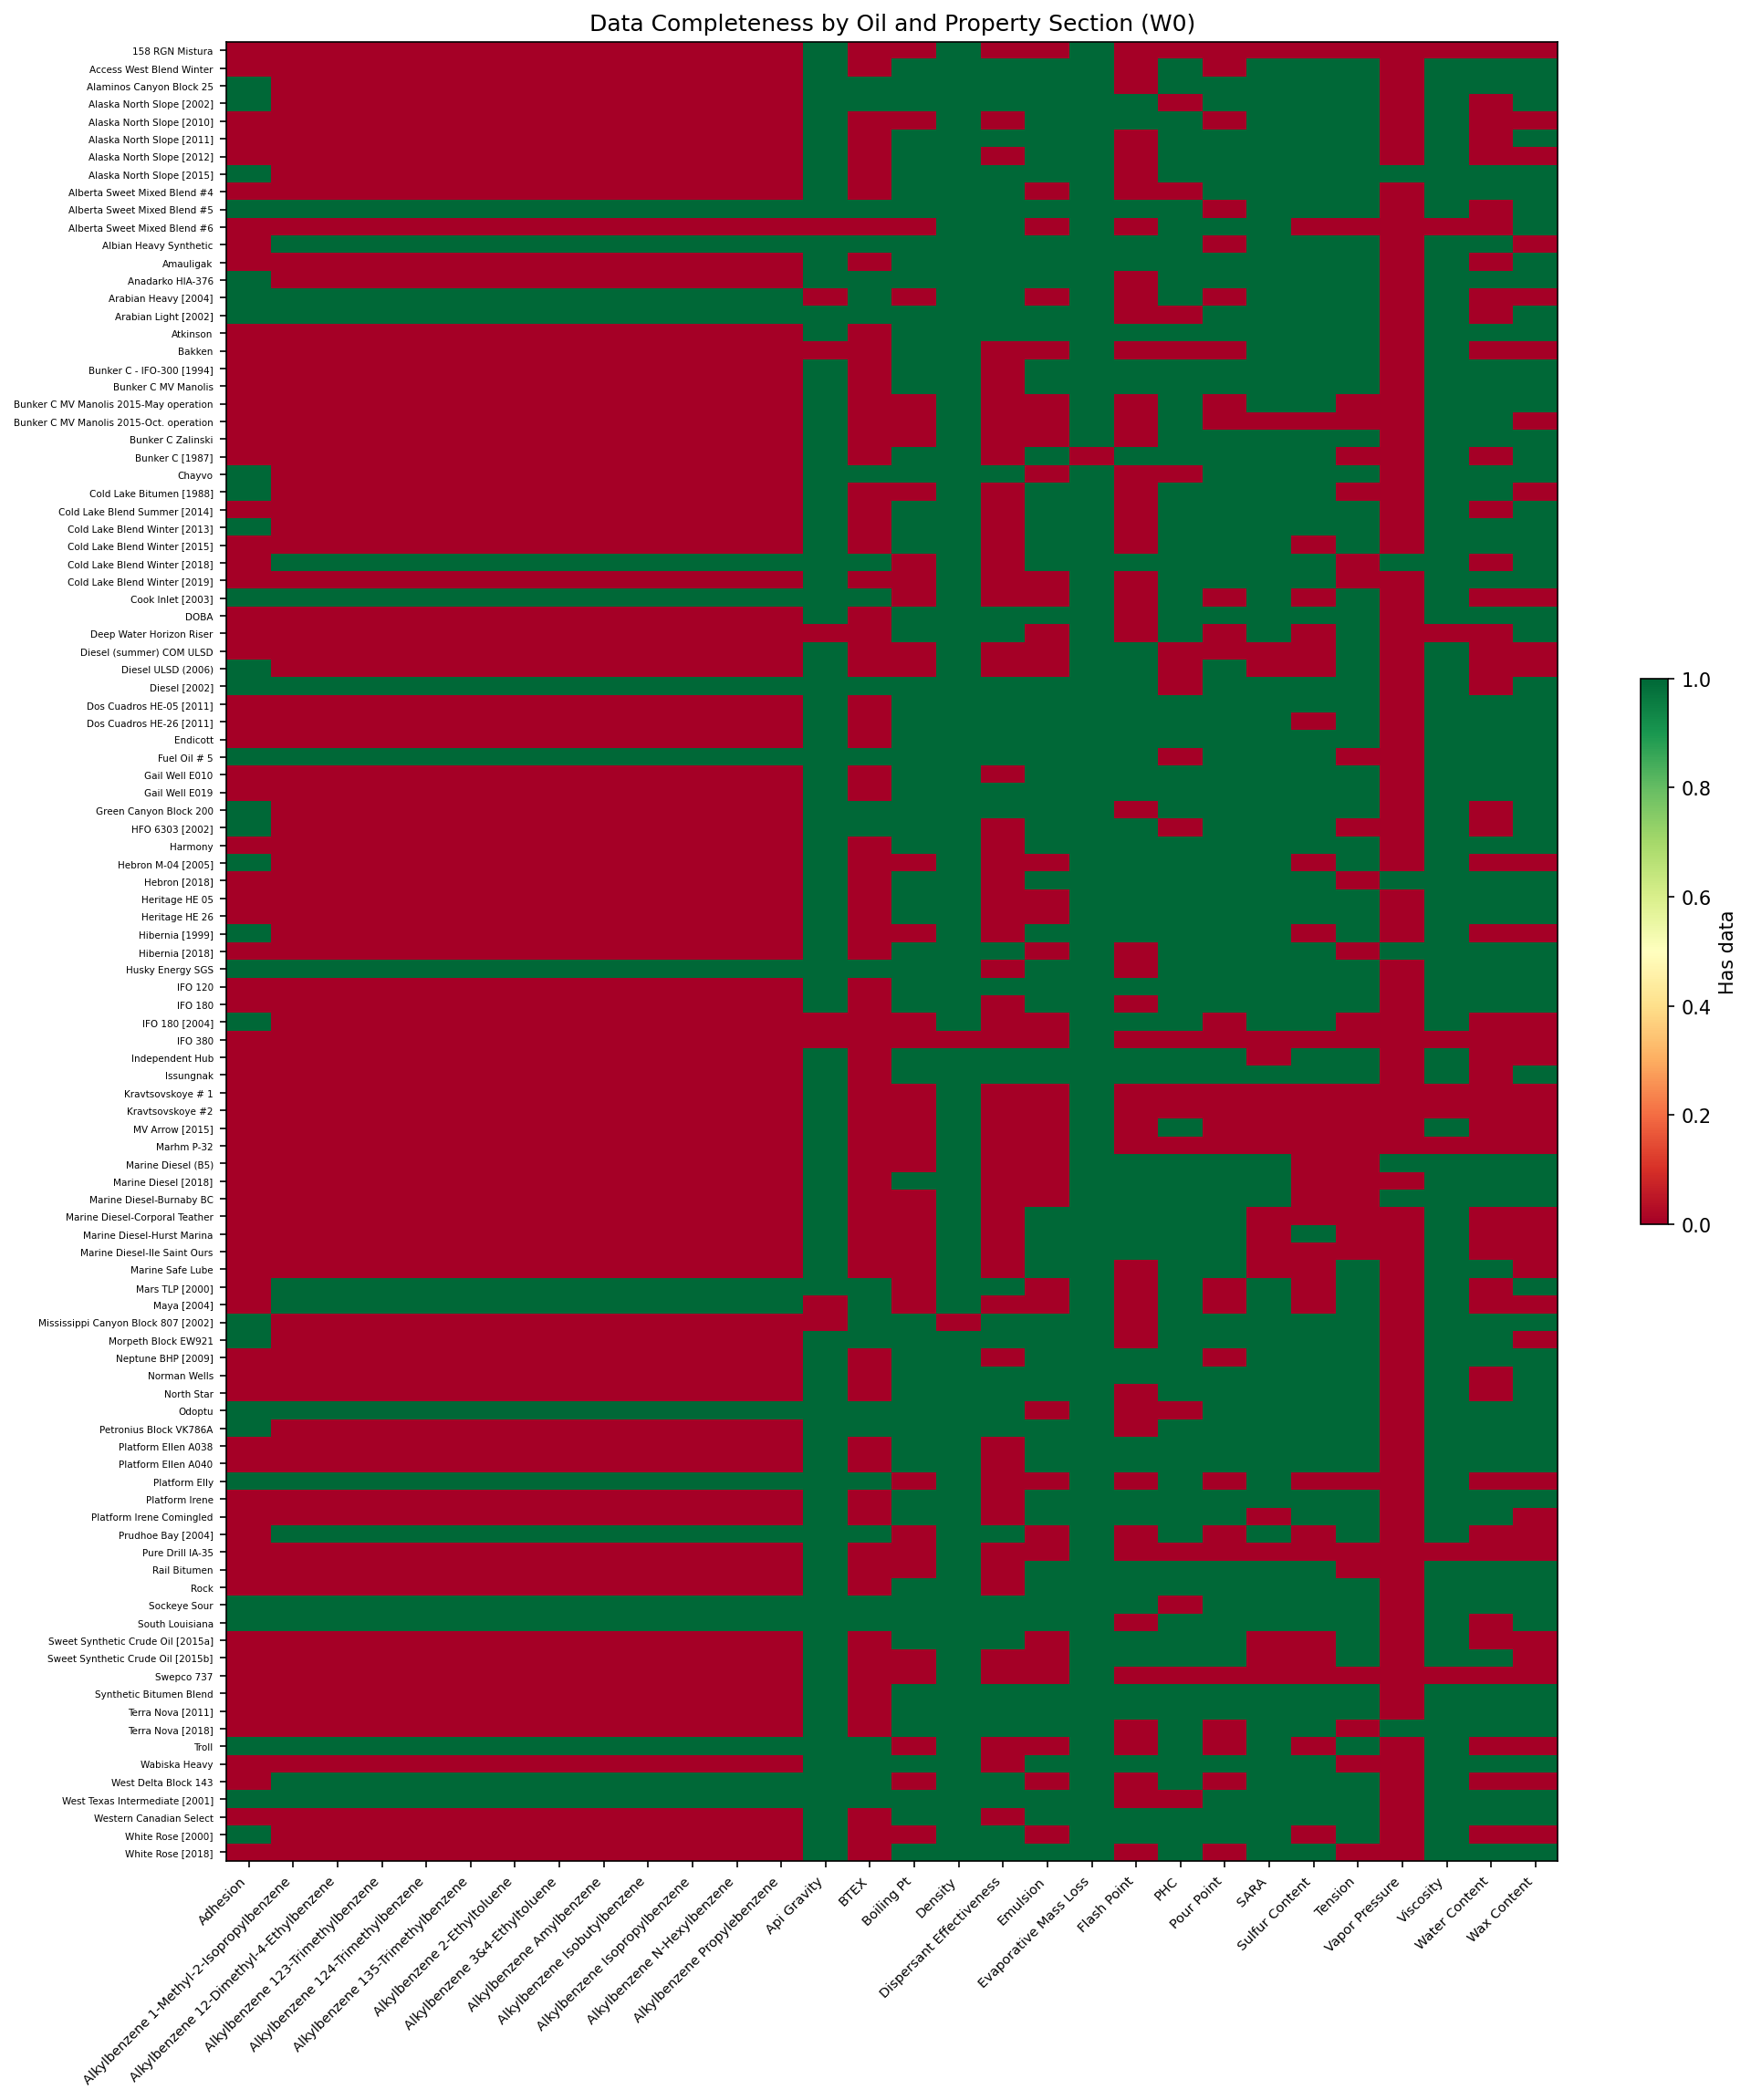

Saved: C:\Users\leogr\Documents\Data Science\TCC\figures\nb01\nb01_missingness_heatmap.png


In [24]:
with get_conn() as conn:
    # Property counts per oil
    df_prop = pd.read_sql("""
        SELECT o.oil_name, o.oil_type, o.include_in_analysis,
               sp.property_name, COUNT(*) as n_records
        FROM sample_properties sp
        JOIN oils o ON sp.oil_id = o.oil_id
        WHERE sp.stage_code = 'W0'
        GROUP BY o.oil_name, sp.property_name
    """, conn)
    
    # Compound missingness per oil
    df_miss = pd.read_sql("""
        SELECT o.oil_name, o.oil_type, o.include_in_analysis,
               c.compound_group, COUNT(*) as n_total,
               SUM(m.is_nd) as n_nd
        FROM measurements m
        JOIN oils o ON m.oil_id = o.oil_id
        JOIN compounds c ON m.compound_id = c.compound_id
        WHERE m.stage_code = 'W0'
        GROUP BY o.oil_name, c.compound_group
    """, conn)

# Pivot: property sections as columns, oils as rows
# Group properties into sections for readability
section_map = {}
for pname in df_prop['property_name'].unique():
    if 'density' in pname:
        section_map[pname] = 'Density'
    elif 'viscosity' in pname:
        section_map[pname] = 'Viscosity'
    elif 'tension' in pname:
        section_map[pname] = 'Tension'
    elif 'bp_' in pname:
        section_map[pname] = 'Boiling Pt'
    elif 'emulsion' in pname:
        section_map[pname] = 'Emulsion'
    elif 'sara' in pname:
        section_map[pname] = 'SARA'
    elif 'btex' in pname:
        section_map[pname] = 'BTEX'
    elif 'phc' in pname:
        section_map[pname] = 'PHC'
    else:
        section_map[pname] = pname.replace('_', ' ').title()

df_prop['section'] = df_prop['property_name'].map(section_map)
pivot = df_prop.groupby(['oil_name', 'section'])['n_records'].sum().unstack(fill_value=0)
# Binary: has data (1) vs no data (0)
binary = (pivot > 0).astype(int)

fig, ax = plt.subplots(figsize=(14, max(8, len(binary) * 0.15)))
im = ax.imshow(binary.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(binary.columns)))
ax.set_xticklabels(binary.columns, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(binary.index)))
ax.set_yticklabels(binary.index, fontsize=5)
ax.set_title('Data Completeness by Oil and Property Section (W0)', fontsize=12)
plt.colorbar(im, ax=ax, shrink=0.3, label='Has data')
plt.tight_layout()
fig_path = FIG_DIR / 'nb01_missingness_heatmap.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))
print(f"Saved: {fig_path}")


## 23. Update `weathering_stages` with empirical statistics

Replace the NULL placeholders from NB00 with actual median, p25, p75
mass loss computed from the included oils. These statistics are used
throughout the pipeline for context (e.g., 'W2 ≈ 18% mass loss').


In [25]:
with get_conn() as conn:
    for stage in ['W0', 'W1', 'W2', 'W3', 'W4']:
        stats = conn.execute("""
            SELECT
                COUNT(*) as n,
                AVG(sp.value) as mean_ml,
                -- SQLite doesn't have PERCENTILE, use subquery
                sp.value as sample_val
            FROM sample_properties sp
            JOIN oils o ON sp.oil_id = o.oil_id
            WHERE sp.property_name = 'evaporative_mass_loss'
              AND sp.stage_code = ?
              AND o.include_in_analysis = 1
        """, (stage,)).fetchone()
        
        # Get all values for percentile calculation
        vals = [r[0] for r in conn.execute("""
            SELECT sp.value FROM sample_properties sp
            JOIN oils o ON sp.oil_id = o.oil_id
            WHERE sp.property_name = 'evaporative_mass_loss'
              AND sp.stage_code = ? AND o.include_in_analysis = 1
            ORDER BY sp.value
        """, (stage,)).fetchall()]
        
        if vals:
            median = np.median(vals)
            p25 = np.percentile(vals, 25)
            p75 = np.percentile(vals, 75)
            conn.execute("""
                UPDATE weathering_stages
                SET mass_loss_pct_median = ?, mass_loss_pct_p25 = ?, mass_loss_pct_p75 = ?
                WHERE stage_code = ?
            """, (round(median, 2), round(p25, 2), round(p75, 2), stage))
            print(f"  {stage}: n={len(vals)}, median={median:.1f}%, "
                  f"IQR=[{p25:.1f}%, {p75:.1f}%]")
        else:
            print(f"  {stage}: no data")

print("\n✓ weathering_stages updated with empirical statistics")


  W0: n=65, median=0.0%, IQR=[0.0%, 0.0%]
  W1: n=63, median=8.8%, IQR=[7.3%, 10.9%]
  W2: n=63, median=17.2%, IQR=[14.8%, 21.3%]
  W3: n=63, median=25.9%, IQR=[22.4%, 32.2%]
  W4: n=9, median=43.0%, IQR=[26.5%, 45.4%]

✓ weathering_stages updated with empirical statistics


## Derive `oil_weathering_kinetics` (W→time per oil)

**Note:** This is a derived analysis, not raw extraction.

**Methodological context (ECCC Analytical Methods, 12.01/12.16):**
The W0-W3 samples were produced by **rotary evaporation at 80°C** (Büchi R220,
135 rpm, up to 48h). The pan evaporation data (15°C, 29 timepoints) is a
**separate measurement** of evaporative kinetics under ambient-like conditions.
The W→time values derived here represent the time the oil would take to reach
each mass loss **at 15°C in a pan** — operationally relevant for field estimation,
but not the actual lab time that produced the weathered fractions.

For each oil with pan evaporation data, interpolate the time at which
the mass loss equals the actual mass loss of each weathering stage.


In [26]:
with get_conn() as conn:
    conn.execute("DELETE FROM oil_weathering_kinetics")
    
    # Get all oils with pan evap data
    pan_oils = conn.execute("""
        SELECT DISTINCT p.oil_id FROM pan_evaporation p
        JOIN oils o ON p.oil_id = o.oil_id
        WHERE o.include_in_analysis = 1
    """).fetchall()
    
    n_inserted = 0
    for (oil_id,) in pan_oils:
        # Get pan evap curve
        curve = conn.execute("""
            SELECT time_hours, mass_loss_pct FROM pan_evaporation
            WHERE oil_id = ? ORDER BY time_hours
        """, (oil_id,)).fetchall()
        if len(curve) < 2:
            continue
        
        times = np.array([r[0] for r in curve])
        losses = np.array([r[1] for r in curve])
        
        # Guard: force monotonicity. Note: ECCC method 12.16/3.0/M applies
        # 3-hour moving average smoothing before reporting, so the data in
        # the CSV is already smoothed. This guard is redundant but preserved
        # as defensive programming for edge cases.
        losses = np.maximum.accumulate(losses)
        
        # Get actual mass loss for each stage
        for stage in ['W0', 'W1', 'W2', 'W3']:
            ml_row = conn.execute("""
                SELECT sp.value FROM sample_properties sp
                WHERE sp.oil_id = ? AND sp.stage_code = ?
                  AND sp.property_name = 'evaporative_mass_loss'
            """, (oil_id, stage)).fetchone()
            if ml_row is None:
                continue
            target_ml = ml_row[0]
            
            if stage == 'W0':
                time_h = 0.0
            elif target_ml <= losses[0]:
                time_h = times[0]
            elif target_ml >= losses[-1]:
                time_h = times[-1]  # extrapolation capped
            else:
                # Linear interpolation
                time_h = float(np.interp(target_ml, losses, times))
            
            conn.execute("""
                INSERT OR REPLACE INTO oil_weathering_kinetics
                (oil_id, stage_code, time_hours, mass_loss_pct, method)
                VALUES (?, ?, ?, ?, 'pan_evaporation_15C_interp')
            """, (oil_id, stage, round(time_h, 2), target_ml))
            n_inserted += 1

print(f"✓ {n_inserted} records inserted into oil_weathering_kinetics")
print(f"  ({len(pan_oils)} oils with pan evaporation data)")


✓ 164 records inserted into oil_weathering_kinetics
  (41 oils with pan evaporation data)


## D14: Uniform zeros → NULL

**Note:** This is an analytical decision, not a data extraction step.
Conceptually belongs in NB03 (EDA). Placed here to ensure `measurements`
is clean before downstream notebooks run. If NB03 is redesigned to handle
this, remove from NB01.

If a compound has `value_imputed = 0` across all 4 stages (W0-W3) for an oil,
it is genuinely absent. Set `value_imputed = NULL`, preserve `value_raw`.

**`missing_pct` vs D14:** `missing_pct` (§18b) is based on `value_raw IS NULL`
(original CSV missingness). D14 sets `value_imputed = NULL` for a different
reason (uniform absence). `excluded` uses original missingness — the more
defensible criterion.


In [27]:
with get_conn() as conn:
    # Find oil×compound pairs where ALL 4 stages have value_imputed = 0
    zeros = conn.execute("""
        SELECT m.oil_id, m.compound_id, COUNT(*) as n_stages
        FROM measurements m
        JOIN oils o ON m.oil_id = o.oil_id
        JOIN compounds c ON m.compound_id = c.compound_id
        WHERE o.include_in_analysis = 1 AND c.excluded = 0
          AND m.stage_code IN ('W0', 'W1', 'W2', 'W3')
          AND m.value_imputed = 0
        GROUP BY m.oil_id, m.compound_id
        HAVING n_stages = 4
    """).fetchall()
    
    n_updated = 0
    for oil_id, compound_id, _ in zeros:
        conn.execute("""
            UPDATE measurements
            SET value_imputed = NULL
            WHERE oil_id = ? AND compound_id = ?
              AND stage_code IN ('W0', 'W1', 'W2', 'W3')
        """, (oil_id, compound_id))
        n_updated += 4  # 4 stages per pair
    
    n_oils_affected = len(set(r[0] for r in zeros))

print(f"✓ D14: {len(zeros)} oil×compound pairs with uniform zeros")
print(f"  {n_updated} measurement records set to NULL")
print(f"  {n_oils_affected} oils affected")
if abs(len(zeros) - 239) > 50:
    print(f"  ⚠️  Expected ~239 pairs, got {len(zeros)} — verify!")


✓ D14: 57 oil×compound pairs with uniform zeros
  228 measurement records set to NULL
  15 oils affected
  ⚠️  Expected ~239 pairs, got 57 — verify!


## 24. Validation and Summary

Final record counts and assertions. If any assertion fails, the pipeline
should stop — downstream notebooks depend on these minimum thresholds.
The summary provides the definitive record counts for documentation.


In [28]:
with get_conn() as conn:
    counts = {}
    for table in ['oils', 'compounds', 'measurements', 'sample_properties',
                  'pan_evaporation', 'evaporation_equations', 'oil_weathering_kinetics']:
        n = conn.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
        counts[table] = n
    
    # Key stats
    n_included = conn.execute(
        "SELECT COUNT(*) FROM oils WHERE include_in_analysis = 1"
    ).fetchone()[0]
    n_compounds = conn.execute(
        "SELECT COUNT(*) FROM compounds WHERE excluded = 0"
    ).fetchone()[0]
    n_prop_names = conn.execute(
        "SELECT COUNT(DISTINCT property_name) FROM sample_properties"
    ).fetchone()[0]
    n_pan_oils = conn.execute(
        "SELECT COUNT(DISTINCT oil_id) FROM pan_evaporation"
    ).fetchone()[0]

print("="*60)
print("NB01 — Database Population Summary")
print("="*60)
for table, n in counts.items():
    print(f"  {table:<25s} {n:>8,} records")
print(f"{'─'*60}")
print(f"  Total records:          {sum(counts.values()):>8,}")
print(f"\nKey statistics:")
print(f"  Oils in analysis:       {n_included}")
print(f"  Compounds (active):     {n_compounds}")
print(f"  Unique properties:      {n_prop_names}")
print(f"  Oils with pan evap:     {n_pan_oils}")
# ── Assertions ──
assert n_included >= 40, f"Too few included oils: {n_included}"
assert n_compounds >= 80, f"Too few active compounds: {n_compounds}"
assert counts['sample_properties'] > 10000, f"Too few properties: {counts['sample_properties']}"
assert counts['pan_evaporation'] > 1000, f"Too few pan evap records: {counts['pan_evaporation']}"

print(f"\n✓ NB01 complete. All assertions passed. Next: NB02 (Diagnostic Ratios)")


NB01 — Database Population Summary
  oils                           120 records
  compounds                      107 records
  measurements                36,594 records
  sample_properties           15,863 records
  pan_evaporation              1,479 records
  evaporation_equations           39 records
  oil_weathering_kinetics        164 records
────────────────────────────────────────────────────────────
  Total records:            54,366

Key statistics:
  Oils in analysis:       62
  Compounds (active):     92
  Unique properties:      127
  Oils with pan evap:     62

✓ NB01 complete. All assertions passed. Next: NB02 (Diagnostic Ratios)
